In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df=pd.read_csv('CICIDS_binary.csv')

In [3]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label_multi_enc,label_binary,label_binary.1
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0,0,0.0,0.0,0,0,0,0,0


In [4]:
print(df.columns)


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [5]:
df = df.loc[:, ~df.columns.duplicated()]
if 'label_binary.1' in df.columns:
    df = df.drop(columns=['label_binary.1'])


In [6]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label_multi_enc,label_binary
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,0,0


In [7]:
df.drop(columns=['label_multi_enc'],inplace=True)

In [8]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,label_binary
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


In [9]:
df.label_binary.value_counts()

label_binary
0    2096484
1     425878
Name: count, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

# Separate features and labels
X = df.drop(columns=['label_binary'])   # all features
y = df['label_binary']                  # binary target

# Stratified split to preserve class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Class distribution in train:\n", y_train.value_counts())
print("Class distribution in test:\n", y_test.value_counts())


Training set size: (2017889, 78)
Test set size: (504473, 78)
Class distribution in train:
 label_binary
0    1677187
1     340702
Name: count, dtype: int64
Class distribution in test:
 label_binary
0    419297
1     85176
Name: count, dtype: int64


### ANOVA

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

# Apply ANOVA F-test on training data only
k = 30  # choose top 30 features (you can change this)
selector = SelectKBest(score_func=f_classif, k=k)
X_train_anova = selector.fit_transform(X_train, y_train)

# Apply same transformation to test data
X_test_anova = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]
print(f"Top {k} features selected by ANOVA:\n", selected_features.tolist())


c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [31 33 56 57 58 59 60 61] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\vp532\OneDrive\Desktop\Mini_Project\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Top 30 features selected by ANOVA:
 ['Destination Port', 'Flow Duration', 'Fwd Packet Length Min', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Bwd IAT Max', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'URG Flag Count', 'Average Packet Size', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']


### Pearson Correlation

In [13]:
import numpy as np

# ANOVA-selected features
X_train_anova_df = pd.DataFrame(X_train_anova, columns=selected_features)

corr_matrix = X_train_anova_df.corr().abs()

#Upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features to drop:", to_drop)

X_train_pcc = X_train_anova_df.drop(columns=to_drop)
X_test_pcc = pd.DataFrame(X_test_anova, columns=selected_features).drop(columns=to_drop)

print("Remaining features after PCC:", X_train_pcc.shape[1])


Highly correlated features to drop: ['Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Max', 'Idle Min']
Remaining features after PCC: 14


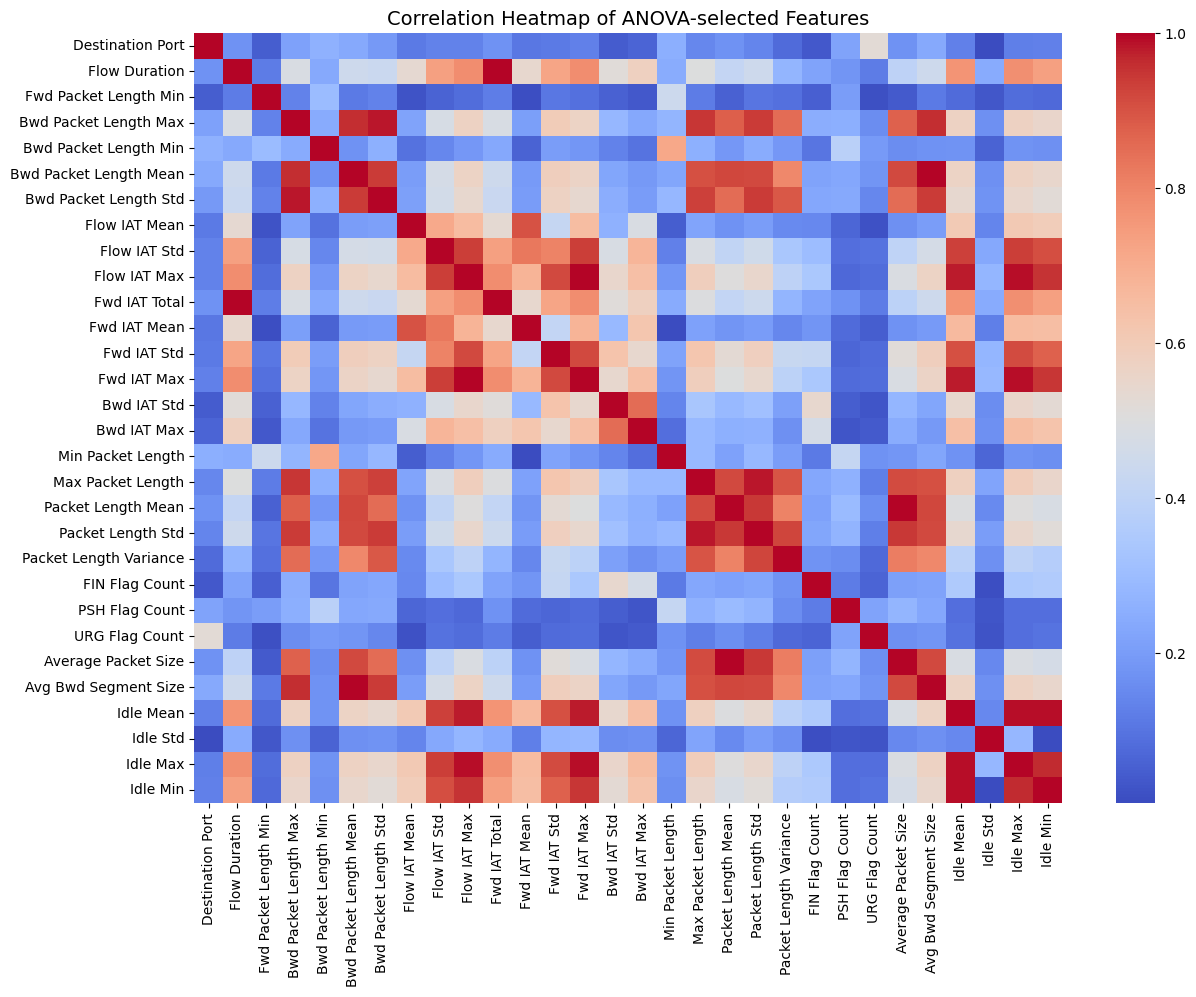

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix for ANOVA-selected features
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, cbar=True)

plt.title("Correlation Heatmap of ANOVA-selected Features", fontsize=14)
plt.show()


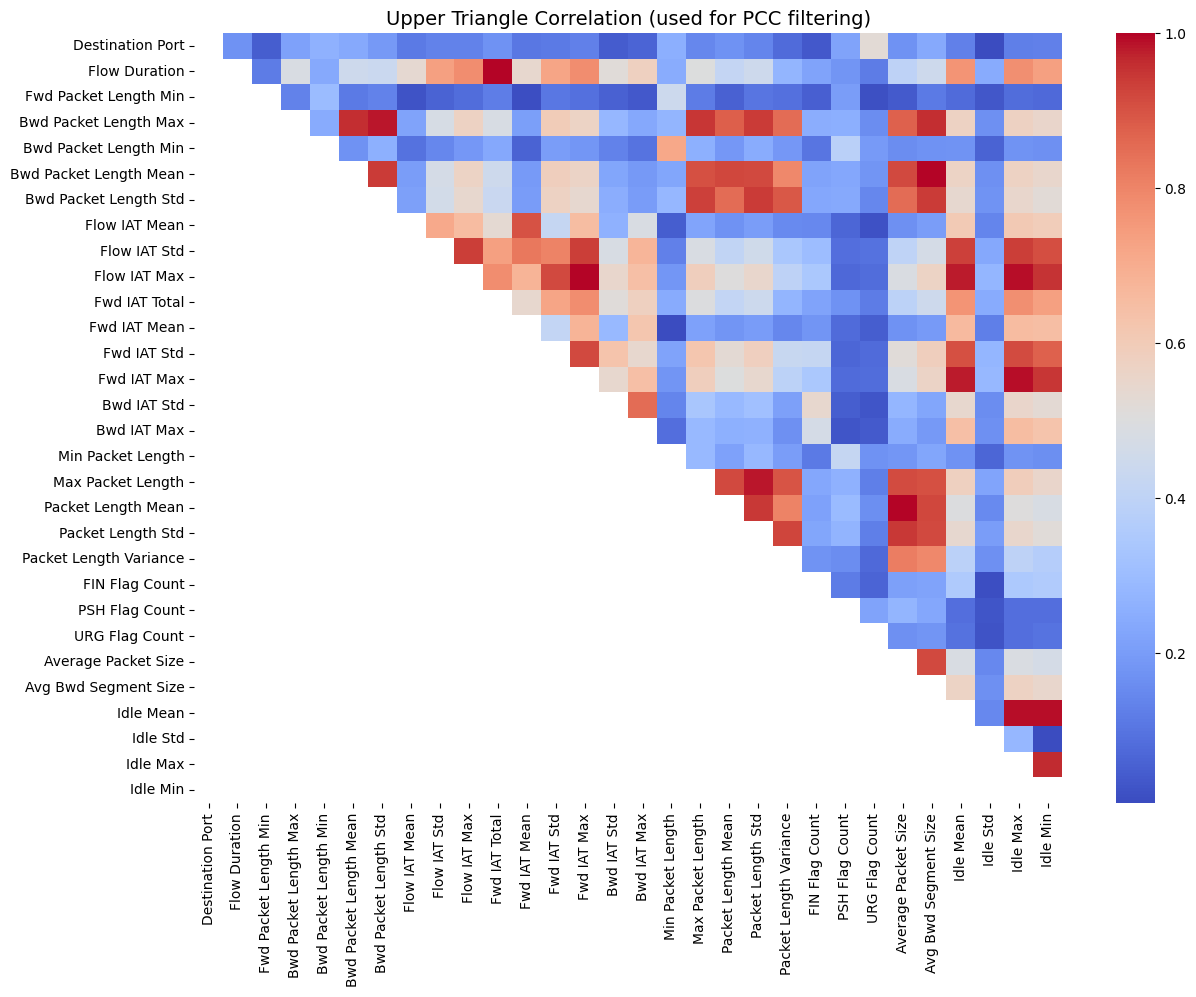

Dropped features due to high correlation (>0.9):
['Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Average Packet Size', 'Avg Bwd Segment Size', 'Idle Mean', 'Idle Max', 'Idle Min']


In [15]:
# Mask upper triangle
plt.figure(figsize=(14,10))
sns.heatmap(upper, cmap="coolwarm", annot=False, cbar=True)

plt.title("Upper Triangle Correlation (used for PCC filtering)", fontsize=14)
plt.show()

print("Dropped features due to high correlation (>0.9):")
print(to_drop)


In [16]:
X_train_pcc

,Destination Port,Flow Duration,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow IAT Mean,Flow IAT Std,Bwd IAT Std,Bwd IAT Max,Min Packet Length,FIN Flag Count,PSH Flag Count,URG Flag Count,Idle Std
0,80.0,168316.0,0.0,4344.0,0.0,1.502821e+03,5.508843e+03,5.730701e+03,30810.0,0.0,0.0,1.0,0.0,0.00000
1,53.0,193.0,41.0,57.0,57.0,6.433333e+01,7.092484e+01,0.000000e+00,48.0,41.0,0.0,0.0,0.0,0.00000
2,80.0,51140032.0,0.0,795.0,0.0,3.196252e+06,4.873991e+06,4.965588e+06,10240114.0,0.0,0.0,1.0,0.0,65220.20106
3,80.0,5797995.0,0.0,0.0,0.0,1.932665e+06,3.327127e+06,0.000000e+00,0.0,0.0,0.0,1.0,0.0,0.00000
4,80.0,85116367.0,0.0,5792.0,0.0,5.319773e+06,2.120000e+07,6.341323e+04,157244.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017884,53.0,68675.0,44.0,102.0,102.0,1.373500e+04,1.887823e+04,0.000000e+00,3.0,44.0,0.0,0.0,0.0,0.00000
2017885,53.0,142225.0,45.0,136.0,136.0,1.422250e+05,0.000000e+00,0.000000e+00,0.0,45.0,0.0,0.0,0.0,0.00000
2017886,80.0,99035703.0,0.0,5792.0,0.0,7.618131e+06,2.750000e+07,8.568139e+03,19131.0,0.0,0.0,0.0,0.0,0.00000
2017887,53.0,251.0,33.0,113.0,113.0,8.366667e+01,1.388536e+02,0.000000e+00,4.0,33.0,0.0,0.0,0.0,0.00000


In [17]:
X_test_pcc

,Destination Port,Flow Duration,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow IAT Mean,Flow IAT Std,Bwd IAT Std,Bwd IAT Max,Min Packet Length,FIN Flag Count,PSH Flag Count,URG Flag Count,Idle Std
0,53.0,176.0,30.0,46.0,46.0,5.866667e+01,6.169549e+01,0.000000e+00,48.0,30.0,0.0,0.0,0.0,0.000000
1,443.0,5295033.0,0.0,152.0,0.0,5.883370e+05,1.596528e+06,1.103680e+05,210918.0,0.0,0.0,1.0,0.0,0.000000
2,53.0,84895.0,56.0,72.0,72.0,8.489500e+04,0.000000e+00,0.000000e+00,0.0,56.0,0.0,0.0,0.0,0.000000
3,80.0,1002.0,0.0,0.0,0.0,2.004000e+02,4.436387e+02,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000
4,53.0,62561.0,66.0,206.0,206.0,6.256100e+04,0.000000e+00,0.000000e+00,0.0,66.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504468,443.0,65416872.0,0.0,1921.0,0.0,2.725703e+06,4.369303e+06,5.031377e+06,10100000.0,0.0,0.0,1.0,0.0,791.912369
504469,80.0,2517618.0,0.0,0.0,0.0,1.258809e+06,1.746643e+06,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000
504470,53.0,215.0,42.0,58.0,58.0,7.166667e+01,4.012896e+01,0.000000e+00,48.0,42.0,0.0,0.0,0.0,0.000000
504471,443.0,11565413.0,0.0,1786.0,0.0,6.425229e+05,2.341694e+06,4.009982e+06,10100000.0,0.0,0.0,1.0,0.0,0.000000


### Embedded method

                  Feature  Importance
3   Bwd Packet Length Max    0.233158
6            Flow IAT Std    0.141569
1           Flow Duration    0.114710
11         PSH Flag Count    0.100534
0        Destination Port    0.084435
4   Bwd Packet Length Min    0.066264
8             Bwd IAT Max    0.061106
5           Flow IAT Mean    0.055478
9       Min Packet Length    0.037390
10         FIN Flag Count    0.036922
7             Bwd IAT Std    0.026414
2   Fwd Packet Length Min    0.024169
12         URG Flag Count    0.010884
13               Idle Std    0.006966


C:\Users\vp532\AppData\Local\Temp\ipykernel_22224\1860033022.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")


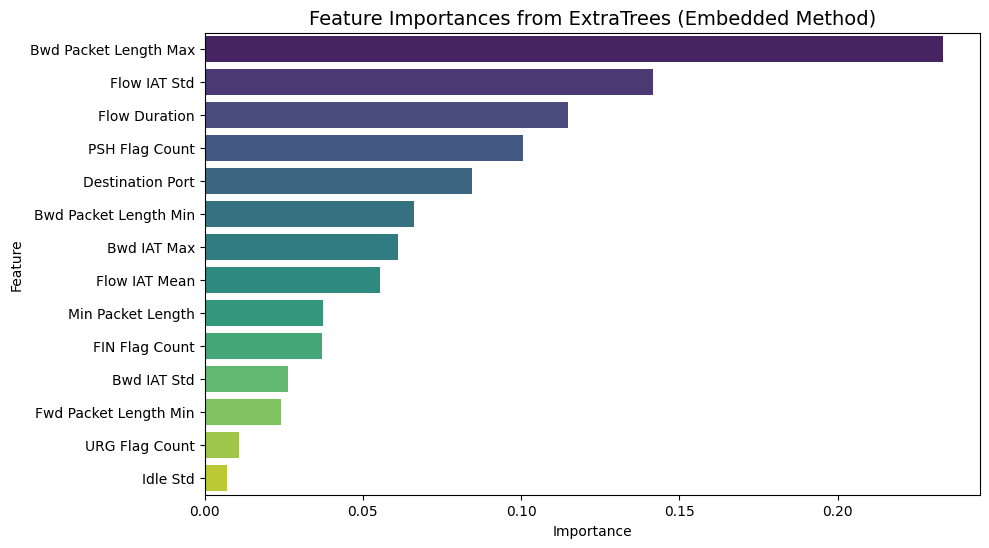

In [19]:
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Train ExtraTrees on the reduced feature set (13 features)
model = ExtraTreesClassifier(n_estimators=200, random_state=42)
model.fit(X_train_pcc, y_train)

# feature importances
importances = model.feature_importances_
features = X_train_pcc.columns

# DataFrame 
feat_importances = pd.DataFrame({"Feature": features, "Importance": importances})
feat_importances = feat_importances.sort_values(by="Importance", ascending=False)

print(feat_importances)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_importances, palette="viridis")
plt.title("Feature Importances from ExtraTrees (Embedded Method)", fontsize=14)
plt.show()


In [20]:
from sklearn.preprocessing import MinMaxScaler

final_features = feat_importances[feat_importances['Importance'] > 0.02]['Feature'].tolist()

# final_features = feat_importances['Feature'].tolist()

print("Final selected features:", final_features)

# Min-Max scaling on final features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_pcc[final_features])
X_test_scaled = scaler.transform(X_test_pcc[final_features])

# Convert back to DataFrames for saving
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=final_features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=final_features)

# Add target column back
train_processed = X_train_scaled_df.copy()
train_processed['label_binary'] = y_train.reset_index(drop=True)

test_processed = X_test_scaled_df.copy()
test_processed['label_binary'] = y_test.reset_index(drop=True)

# Combine for saving full processed dataset
processed = pd.concat([train_processed, test_processed], axis=0)

# Save processed dataset
processed.to_csv("CICIDS_Binary_processed.csv", index=False)

print("✅ Saved processed dataset as CICIDS_Binary_processed.csv")
print("Shape:", processed.shape)


Final selected features: ['Bwd Packet Length Max', 'Flow IAT Std', 'Flow Duration', 'PSH Flag Count', 'Destination Port', 'Bwd Packet Length Min', 'Bwd IAT Max', 'Flow IAT Mean', 'Min Packet Length', 'FIN Flag Count', 'Bwd IAT Std', 'Fwd Packet Length Min']
✅ Saved processed dataset as CICIDS_Binary_processed.csv
Shape: (2522362, 13)
